In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from flimkit.PTU.reader    import PTUFile
from flimkit.PTU.decode    import get_flim_histogram_from_ptufile
from flimkit.FLIM.fitters  import fit_summed, fit_per_pixel
from flimkit.FLIM.irf_tools import build_machine_irf_from_folder
from flimkit.FLIM.assemble import assemble_tile_maps, derive_global_tau, save_assembled_maps
from flimkit.utils.xml_utils import (
    parse_xlif_tile_positions,
    get_pixel_size_from_xlif,
    compute_tile_pixel_positions,
)
from flimkit.configs import (
    MACHINE_IRF_DEFAULT_PATH, MACHINE_IRF_DIR,
    MACHINE_IRF_FIT_BG, MACHINE_IRF_FIT_SIGMA, MACHINE_IRF_FIT_TAIL,
    MACHINE_IRF_DE_POPULATION, MACHINE_IRF_DE_MAXITER,
    MIN_PHOTONS_PERPIX, Tau_min, Tau_max, n_exp, binning_factor,
    Cost_function, Optimizer, lm_restarts, n_workers, FLIM_CMAP,
)

print("Imports OK ✓")
print(f"  Machine IRF : {MACHINE_IRF_DEFAULT_PATH}")
print(f"  n_exp={n_exp}  τ=[{Tau_min},{Tau_max}] ns  cost={Cost_function}  opt={Optimizer}")


Imports OK ✓
  Machine IRF : /Users/as-hunt/FLIMKit/flimkit/machine_irf/machine_irf_default.npy
  n_exp=3  τ=[0.145,45.0] ns  cost=poisson  opt=de


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
MACHINE_IRF_NPY  = MACHINE_IRF_DEFAULT_PATH
MACHINE_IRF_META = Path(str(MACHINE_IRF_NPY).replace('.npy', '_meta.json'))

SINGLE_PTU   = Path("/Volumes/Lexar/2026_02_27_10_38_30--More_to_test/PTU.sptw/A_Control_s10.ptu")   # single-FOV test
XLIF_PATH    = Path("/Volumes/Lexar/2026_02_27_10_38_30--More_to_test/Metadata/A_Control.xlif")        # tiled ROI metadata
PTU_DIR      = Path("/Volumes/Lexar/2026_02_27_10_38_30--More_to_test/PTU.sptw/")
PTU_BASENAME = "A_Control"
OUTPUT_DIR   = Path("output/")

# Fitting parameters
N_EXP       = n_exp
TAU_MIN     = Tau_min
TAU_MAX     = Tau_max
COST_FN     = Cost_function
BINNING     = binning_factor
MIN_PHOTONS = MIN_PHOTONS_PERPIX
FIT_BG      = MACHINE_IRF_FIT_BG
FIT_SIGMA   = MACHINE_IRF_FIT_SIGMA
FIT_TAIL    = MACHINE_IRF_FIT_TAIL

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Config OK ✓")


Config OK ✓


In [3]:
# ── (Optional) Build machine IRF from PTU+XLSX pairs ─────────────────────────
BUILD_FROM_FOLDER = False  # set True to rebuild

if BUILD_FROM_FOLDER:
    result = build_machine_irf_from_folder(
        folder       = Path("data/calibration_pairs/"),
        align_anchor = "peak",
        reducer      = "median",
        save         = True,
        confirm_save = True,
        output_name  = "machine_irf_default",
        output_dir   = MACHINE_IRF_DIR,
        verbose      = True,
    )
    MACHINE_IRF_NPY  = Path(result['save_paths']['npy'])
    MACHINE_IRF_META = Path(result['save_paths']['meta_json'])
    print(f"Built from {result['metadata']['n_pairs']} pairs → {MACHINE_IRF_NPY}")
else:
    print("Skipping build — using existing machine IRF")


Skipping build — using existing machine IRF


In [4]:
# ── Load machine IRF ──────────────────────────────────────────────────────────
if not MACHINE_IRF_NPY.exists():
    raise FileNotFoundError(
        f"Machine IRF not found: {MACHINE_IRF_NPY}\n"
        f"Run the build cell above, or copy machine_irf_default.npy to {MACHINE_IRF_DIR}")

machine_irf = np.asarray(np.load(str(MACHINE_IRF_NPY)), dtype=float).ravel()
machine_irf = np.maximum(machine_irf, 0.0)
machine_irf /= machine_irf.sum()

PI_MACHINE = int(np.argmax(machine_irf))
N_MACHINE  = len(machine_irf)

meta = json.loads(MACHINE_IRF_META.read_text()) if MACHINE_IRF_META.exists() else {}
BW_NS = meta.get('tcspc_res_ns_mean', 0.09696970)

print(f"Machine IRF loaded: {N_MACHINE} bins, peak bin {PI_MACHINE}")
print(f"  BW={BW_NS*1000:.3f} ps  n_pairs={meta.get('n_pairs','?')}  "
      f"reducer={meta.get('reducer','?')}")
nz = machine_irf > 0
print(f"  Non-zero: bins {np.where(nz)[0][0]}–{np.where(nz)[0][-1]}  ({nz.sum()} bins)")
print(f"  Shape:")
for i in np.where(nz)[0]:
    bar = '█' * int(machine_irf[i]/machine_irf.max()*25)
    print(f"    {i-PI_MACHINE:+3d}  {machine_irf[i]/machine_irf.max():.4f}  {bar}")


Machine IRF loaded: 526 bins, peak bin 29
  BW=96.970 ps  n_pairs=26  reducer=median
  Non-zero: bins 19–31  (13 bins)
  Shape:
    -10  0.0000  
     -9  0.0000  
     -8  0.0000  
     -7  0.0000  
     -6  0.0000  
     -5  0.0000  
     -4  0.0001  
     -3  0.0046  
     -2  0.0831  ██
     -1  0.4574  ███████████
     +0  1.0000  █████████████████████████
     +1  0.5741  ██████████████
     +2  0.0000  


In [5]:
def get_tile_irf(tile_peak_bin: int, n_bins: int) -> np.ndarray:
    """
    Shift machine IRF peak to tile_peak_bin.
    Matches _load_machine_irf_prompt() in interactive.py exactly:
    clip/pad to n_bins, then np.roll(shift) where shift = tile_peak_bin - PI_MACHINE.
    """
    irf = machine_irf.copy()
    if irf.size > n_bins:
        irf = irf[:n_bins]
    elif irf.size < n_bins:
        padded = np.zeros(n_bins, dtype=float)
        padded[:irf.size] = irf
        irf = padded
    shift = tile_peak_bin - PI_MACHINE
    if shift != 0:
        irf = np.roll(irf, shift)
    s = irf.sum()
    if s <= 0:
        raise ValueError(f"IRF all-zero after shift to peak_bin={tile_peak_bin}")
    return irf / s

# Sanity check
_t = get_tile_irf(PI_MACHINE, N_MACHINE)
assert abs(_t.sum() - 1.0) < 1e-9 and np.argmax(_t) == PI_MACHINE
print("get_tile_irf() ✓")

def adapt_pixel_maps(pixel_maps: dict, n_exp: int, taus_ns: np.ndarray) -> dict:
    """
    Remap fit_per_pixel output keys to assemble_tile_maps format.

    fit_per_pixel returns:  intensity, tau_mean_amp, tau_mean_int, chi2_r,
                            alpha_1..N, frac_1..N
    assemble_tile_maps needs: intensity, tau_mean_amp, chi2,
                              tau1..N, a1..N

    Lifetimes are fixed scalars from the summed fit — broadcast to pixel maps.
    """
    adapted = {
        'intensity':   pixel_maps['intensity'],
        'tau_mean_amp': pixel_maps['tau_mean_amp'],
        'chi2':        pixel_maps['chi2_r'],    # key rename only
    }
    ny, nx = pixel_maps['intensity'].shape
    for k in range(1, n_exp + 1):
        # tau_k is a fixed scalar from summed fit — fill the whole tile
        adapted[f'tau{k}'] = np.full((ny, nx), taus_ns[k-1], dtype=np.float32)
        adapted[f'a{k}']   = pixel_maps.get(f'alpha_{k}',
                              np.full((ny, nx), np.nan, dtype=np.float32))
    return adapted

print("adapt_pixel_maps() ✓")


get_tile_irf() ✓
adapt_pixel_maps() ✓


In [6]:
# ── Single-FOV: load PTU → summed fit → per-pixel fit ────────────────────────
if not SINGLE_PTU.exists():
    print(f"⚠  {SINGLE_PTU} not found — update SINGLE_PTU in config cell")
else:
    ptu    = PTUFile(str(SINGLE_PTU), verbose=False)
    decay  = ptu.summed_decay()
    n_bins = ptu.n_bins
    tcspc  = ptu.tcspc_res
    peak_bin = int(np.argmax(decay))
    irf      = get_tile_irf(peak_bin, n_bins)

    print(f"PTU  : {SINGLE_PTU.name}")
    print(f"  {n_bins} bins × {tcspc*1e12:.2f} ps  |  peak bin {peak_bin}  |  "
          f"{decay.sum():,.0f} photons")
    print(f"  IRF shift: {PI_MACHINE} → {peak_bin}  (Δ={peak_bin-PI_MACHINE:+d})")
    print()

    # ── Summed fit ─────────────────────────────────────────────────────────
    popt, summary = fit_summed(
        decay, tcspc, n_bins, irf,
        has_tail      = FIT_TAIL,
        fit_bg        = FIT_BG,
        fit_sigma     = FIT_SIGMA,
        n_exp         = N_EXP,
        tau_min_ns    = TAU_MIN,
        tau_max_ns    = TAU_MAX,
        optimizer     = Optimizer,
        cost_function = COST_FN,
        n_restarts    = lm_restarts,
        workers       = n_workers,
    )
    taus_ns = summary['taus_ns']   # sorted descending

    print()
    print(f"  τ = {[f'{t:.3f}' for t in taus_ns]} ns")
    print(f"  χ²_r (tail) = {summary['reduced_chi2_tail']:.4f}  "
          f"χ²_r (full) = {summary['reduced_chi2']:.4f}")

    # ── Per-pixel fit ───────────────────────────────────────────────────────
    print()
    hist, tmeta = get_flim_histogram_from_ptufile(
        SINGLE_PTU, rotate_cw=True, binning=BINNING, channel=None)

    pixel_maps = fit_per_pixel(
        hist.astype(float), tcspc, n_bins, irf,
        has_tail    = FIT_TAIL,
        fit_bg      = FIT_BG,
        fit_sigma   = FIT_SIGMA,
        global_popt = popt,
        n_exp       = N_EXP,
        min_photons = MIN_PHOTONS,
    )
    print(f"  pixel_maps keys: {list(pixel_maps.keys())}")


PTU  : A_Control_s10.ptu
  525 bins × 96.97 ps  |  peak bin 28  |  10,870 photons
  IRF shift: 29 → 28  (Δ=-1)

  Next-period artefact at bin 490 (47.52 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 3.000 cts/bin, upper bound = 13.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=15, maxiter=1000, workers=-1
  Running final LM polish...

  τ = ['5.180', '1.275', '0.327'] ns
  χ²_r (tail) = 1.3425  χ²_r (full) = 1.3357

  Per-pixel fitting: 512×512=262144 pixels (τ fixed, amplitudes + bg free) …


  Per-pixel rows: 100%|██████████| 512/512 [00:00<00:00, 2226.16it/s]

  Fitted: 95/262144  |  Skipped (<10 ph): 262049  |  0.2s
  pixel_maps keys: ['intensity', 'tau_mean_int', 'tau_mean_amp', 'chi2_r', 'alpha_1', 'frac_1', 'tau_1', 'a1', 'alpha_2', 'frac_2', 'tau_2', 'a2', 'alpha_3', 'frac_3', 'tau_3', 'a3']


In [7]:
# ── Tiled ROI: Step 1 — pool decays → consensus fit_summed ───────────────────
# Uses PTUFile.summed_decay() — reads photon records only, no pixel stack.
# The full pixel stack is loaded once in Pass 2 only, saving ~60 GB of I/O.

if not XLIF_PATH.exists():
    print(f"⚠  XLIF not found: {XLIF_PATH}")
else:
    tile_positions = parse_xlif_tile_positions(XLIF_PATH, PTU_BASENAME)
    pixel_size_m, _ = get_pixel_size_from_xlif(XLIF_PATH)
    tile_positions, canvas_w, canvas_h = compute_tile_pixel_positions(
        tile_positions, pixel_size_m, 512)

    print(f"ROI    : {PTU_BASENAME}")
    print(f"Tiles  : {len(tile_positions)}  |  canvas {canvas_h}×{canvas_w} px")
    print(f"\nPass 1: accumulating pooled decay (summed_decay only, no pixel stack)...")

    tile_meta    = []    # lightweight metadata only — no histograms
    pooled_decay = None
    n_bins_ref   = None
    tcspc_ref    = None

    for i, t in enumerate(tile_positions):
        ptu_path = PTU_DIR / t['file']
        if not ptu_path.exists():
            print(f"  MISSING  {t['file']}"); continue

        ptu    = PTUFile(str(ptu_path), verbose=False)
        decay  = ptu.summed_decay()
        n_bins = ptu.n_bins
        tcspc  = ptu.tcspc_res

        peak_bin = int(np.argmax(decay))
        irf      = get_tile_irf(peak_bin, n_bins)

        if pooled_decay is None:
            pooled_decay = decay.copy()
            n_bins_ref   = n_bins
            tcspc_ref    = tcspc
        else:
            # Expand pooled array if this tile has more bins
            if n_bins > n_bins_ref:
                pooled_decay = np.pad(pooled_decay, (0, n_bins - n_bins_ref))
                n_bins_ref   = n_bins
            if len(decay) < len(pooled_decay):
                decay = np.pad(decay, (0, len(pooled_decay) - len(decay)))
            pooled_decay[:len(decay)] += decay[:len(pooled_decay)]

        tile_meta.append({
            'file':     t['file'],
            't':        t,
            'n_bins':   n_bins,
            'tcspc':    tcspc,
            'peak_bin': peak_bin,
        })

        if (i + 1) % 20 == 0 or (i + 1) == len(tile_positions):
            print(f"  {i+1}/{len(tile_positions)} tiles read  "
                  f"({pooled_decay.sum():,.0f} photons so far)")

    print(f"\n  Pooled: {len(tile_meta)} tiles  |  "
          f"{pooled_decay.sum():,.0f} photons  |  "
          f"peak bin {int(np.argmax(pooled_decay))}")

    # ── Consensus fit_summed on pooled decay ───────────────────────────────
    pooled_peak = int(np.argmax(pooled_decay))
    pooled_irf  = get_tile_irf(pooled_peak, n_bins_ref)

    print("\nRunning consensus fit_summed on pooled decay...")
    global_popt, global_summary = fit_summed(
        pooled_decay, tcspc_ref, n_bins_ref, pooled_irf,
        has_tail      = FIT_TAIL,
        fit_bg        = FIT_BG,
        fit_sigma     = FIT_SIGMA,
        n_exp         = N_EXP,
        tau_min_ns    = TAU_MIN,
        tau_max_ns    = TAU_MAX,
        optimizer     = Optimizer,
        cost_function = COST_FN,
        n_restarts    = lm_restarts,
        workers       = n_workers,
    )
    consensus_taus_ns = global_summary['taus_ns']
    print(f"\n  Consensus τ = {[f'{t:.3f}' for t in consensus_taus_ns]} ns")
    print(f"  χ²_r (tail) = {global_summary['reduced_chi2_tail']:.4f}")
    print(f"  τ and IRF fixed for all {len(tile_meta)} per-pixel fits.")


ROI    : A_Control
Tiles  : 76  |  canvas 4198×5581 px

Pass 1: accumulating pooled decay (summed_decay only, no pixel stack)...
  20/76 tiles read  (5,259,869 photons so far)
  40/76 tiles read  (9,706,118 photons so far)
  60/76 tiles read  (13,095,067 photons so far)
  76/76 tiles read  (13,413,234 photons so far)

  Pooled: 76 tiles  |  13,413,234 photons  |  peak bin 28

Running consensus fit_summed on pooled decay...
  Cost function: poisson
  bg initial guess = 536.000 cts/bin, upper bound = 1072.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=15, maxiter=1000, workers=-1
  Running final LM polish...

  Consensus τ = ['6.949', '2.219', '0.539'] ns
  χ²_r (tail) = 3.0221
  τ and IRF fixed for all 76 per-pixel fits.


In [8]:
# ── Tiled ROI: Step 2 — per-pixel fit ────────────────────────────────────────
# Uses raw_pixel_stack(channel=ptu.photon_channel) — exactly as
# make_intensity_image() does in flimkit/image/tools.py.
# raw_pixel_stack is the overflow-corrected path; pixel_stack uses a different
# assignment algorithm and can give inconsistent counts.

if 'tile_meta' not in dir() or not tile_meta:
    print("Run Pass 1 first")
else:
    popt_for_px             = global_popt.copy()
    popt_for_px[2 * N_EXP] = 0.0   # zero shift — pooled_irf already aligned

    tile_results = []
    print(f"Pass 2: per-pixel fit ({len(tile_meta)} tiles)")
    print(f"  Fixed τ        = {[f'{t:.3f}' for t in consensus_taus_ns]} ns")
    print(f"  Fixed IRF      = pooled_irf (peak bin {pooled_peak})")
    print(f"  irf_shift_bins   {global_popt[2*N_EXP]:.4f} → zeroed\n")

    for tc in tile_meta:
        ptu_path = PTU_DIR / tc['file']

        ptu = PTUFile(str(ptu_path), verbose=False)
        ptu.summed_decay()                                   # sets photon_channel
        stack  = ptu.raw_pixel_stack(channel=ptu.photon_channel,
                                      binning=BINNING)       # (Y, X, H) uint32
        stack  = np.rot90(stack, k=-1, axes=(0,1))           # 90° CW — matches stitch
        n_bins = ptu.n_bins
        tcspc  = ptu.tcspc_res
        tile_h, tile_w = stack.shape[:2]

        # Pad or crop pooled_irf to match this tile's n_bins
        if len(pooled_irf) < n_bins:
            irf_tile = np.pad(pooled_irf, (0, n_bins - len(pooled_irf)))
        else:
            irf_tile = pooled_irf[:n_bins]
        irf_tile = irf_tile / irf_tile.sum()

        pixel_maps_raw = fit_per_pixel(
            stack.astype(float),
            tcspc, n_bins,
            irf_tile,
            has_tail    = FIT_TAIL,
            fit_bg      = FIT_BG,
            fit_sigma   = FIT_SIGMA,
            global_popt = popt_for_px,
            n_exp       = N_EXP,
            min_photons = MIN_PHOTONS,
        )
        pixel_maps = adapt_pixel_maps(pixel_maps_raw, N_EXP, consensus_taus_ns)
        del stack

        n_fitted = int(np.isfinite(pixel_maps['tau_mean_amp']).sum())
        tile_results.append({
            'pixel_maps': pixel_maps,
            'pixel_y':    tc['t']['pixel_y'],
            'pixel_x':    tc['t']['pixel_x'],
            'tile_h':     tile_h,
            'tile_w':     tile_w,
            'peak_bin':   tc['peak_bin'],
            'taus_ns':    consensus_taus_ns,
            'n_photons':  int(pixel_maps['intensity'].sum()),
        })
        print(f"  ✓  {tc['file']:<30}  "
              f"{tile_results[-1]['n_photons']:>10,.0f} ph  "
              f"fitted={n_fitted}")

    print(f"\n{len(tile_results)}/{len(tile_meta)} tiles complete")


Pass 2: per-pixel fit (76 tiles)
  Fixed τ        = ['6.949', '2.219', '0.539'] ns
  Fixed IRF      = pooled_irf (peak bin 28)
  irf_shift_bins   -0.8159 → zeroed

  Per-pixel fitting: 512×512=262144 pixels (τ fixed, amplitudes + bg free) …


  Per-pixel rows: 100%|██████████| 512/512 [00:00<00:00, 2321.29it/s]


  Fitted: 1/262144  |  Skipped (<10 ph): 262143  |  0.2s
  ✓  A_Control_s1.ptu                    10,432 ph  fitted=1
  Per-pixel fitting: 512×512=262144 pixels (τ fixed, amplitudes + bg free) …


  Per-pixel rows: 100%|██████████| 512/512 [00:00<00:00, 2236.77it/s]


  Fitted: 2/262144  |  Skipped (<10 ph): 262142  |  0.2s
  ✓  A_Control_s2.ptu                    11,879 ph  fitted=2
  Per-pixel fitting: 512×512=262144 pixels (τ fixed, amplitudes + bg free) …


...

  Fitted: 7/262144  |  Skipped (<10 ph): 262137  |  0.3s
  ✓  A_Control_s74.ptu                    1,008 ph  fitted=7
  Per-pixel fitting: 512×512=262144 pixels (τ fixed, amplitudes + bg free) …


  Per-pixel rows: 100%|██████████| 512/512 [00:01<00:00, 493.70it/s]


  Fitted: 3/262144  |  Skipped (<10 ph): 262141  |  1.0s
  ✓  A_Control_s75.ptu                      793 ph  fitted=3
  Per-pixel fitting: 512×512=262144 pixels (τ fixed, amplitudes + bg free) …


  Per-pixel rows: 100%|██████████| 512/512 [00:01<00:00, 428.93it/s]

  Fitted: 2/262144  |  Skipped (<10 ph): 262142  |  1.2s
  ✓  A_Control_s76.ptu                      875 ph  fitted=2

76/76 tiles complete


In [9]:
# ── Weighted-average assembly (normalises overlap regions) ───────────────────
# assemble_tile_maps uses winner-takes-all which leaves overlap regions
# photometrically inconsistent with single-coverage regions. This replaces it
# with intensity-weighted averaging: each pixel value is the weighted mean
# across all tiles covering it, weighted by that tile's photon count at that
# pixel. Equivalent to how stitch_flim_tiles normalises the histogram cube.

def assemble_tile_maps_normalised(
        tile_results: list,
        canvas_h: int,
        canvas_w: int,
        n_exp: int) -> dict:
    """
    Intensity-weighted average assembly of per-tile pixel maps.

    For each canvas pixel covered by N tiles:
        value[y,x] = Σ(value_k[y,x] × intensity_k[y,x]) / Σ(intensity_k[y,x])

    Single-coverage pixels are unaffected. Overlap pixels are the photon-count
    weighted mean of all contributing tiles — consistent with stitch_flim_tiles
    which divides the accumulated histogram cube by the weight map.
    """
    # Accumulate weighted sums and total weights
    keys_tau = [f'tau{k}' for k in range(1, n_exp + 1)]
    keys_amp = [f'a{k}'   for k in range(1, n_exp + 1)]
    keys_all = keys_tau + keys_amp + ['tau_mean_amp', 'chi2']

    wsum  = {k: np.zeros((canvas_h, canvas_w), dtype=np.float64) for k in keys_all}
    wt    = np.zeros((canvas_h, canvas_w), dtype=np.float64)   # Σ intensity
    intensity_canvas = np.zeros((canvas_h, canvas_w), dtype=np.float32)
    coverage = np.zeros((canvas_h, canvas_w), dtype=np.uint16)

    for tr in tile_results:
        pm = tr.get('pixel_maps')
        if pm is None:
            continue

        y0, x0 = tr['pixel_y'], tr['pixel_x']
        th, tw  = tr['tile_h'],  tr['tile_w']
        y1 = min(y0 + th, canvas_h)
        x1 = min(x0 + tw, canvas_w)
        dy, dx = y1 - y0, x1 - x0

        tile_int = np.asarray(pm['intensity'], dtype=np.float64)[:dy, :dx]
        wt[y0:y1, x0:x1]            += tile_int
        intensity_canvas[y0:y1, x0:x1] += tile_int.astype(np.float32)
        coverage[y0:y1, x0:x1]      += 1

        for key in keys_all:
            src = pm.get(key)
            if src is None:
                continue
            src = np.asarray(src, dtype=np.float64)[:dy, :dx]
            # NaN pixels contribute zero weight (unfitted pixels)
            valid = np.isfinite(src)
            wsum[key][y0:y1, x0:x1] += np.where(valid, src * tile_int, 0.0)

    # Normalise
    canvas = {'intensity': intensity_canvas, 'coverage': coverage.astype(np.float32)}
    safe_wt = np.where(wt > 0, wt, np.nan)

    for key in keys_all:
        result = wsum[key] / safe_wt
        # pixels with no coverage stay NaN
        canvas[key] = result.astype(np.float32)

    # intensity_canvas: average over tiles covering each pixel (matches stitch norm)
    canvas['intensity'] = (intensity_canvas / np.where(coverage > 0, coverage, 1)
                            ).astype(np.float32)

    n_overlap = int((coverage > 1).sum())
    print(f"  Canvas {canvas_h}×{canvas_w}  |  "
          f"overlap pixels: {n_overlap} ({n_overlap/(canvas_h*canvas_w)*100:.1f}%)  |  "
          f"max coverage: {coverage.max()}×")

    return canvas


if 'tile_results' not in dir() or not tile_results:
    print("No tile results — run per-tile loop first")
else:
    canvas = assemble_tile_maps_normalised(tile_results, canvas_h, canvas_w, N_EXP)

    global_summary = derive_global_tau(canvas, N_EXP)

    print("── Global ROI summary ───────────────────────────────────")
    for k, v in global_summary.items():
        print(f"  {k:<40}: {v}")

    save_assembled_maps(
        canvas, global_summary,
        output_dir = OUTPUT_DIR,
        roi_name   = PTU_BASENAME.replace(' ', '_'),
        n_exp      = N_EXP,
    )
    print(f"\nOutputs → {OUTPUT_DIR}")


  Canvas 4198×5581  |  overlap pixels: 2972324 (12.7%)  |  max coverage: 4×
── Global ROI summary ───────────────────────────────────
  n_pixels_fitted                         : 254102
  tau_mean_amp_global_ns                  : 3.94588565826416
  tau_std_amp_global_ns                   : 2.2415695190429688
  tau_median_amp_global_ns                : 4.4066667556762695
  tau1_mean_ns                            : 6.949188232421875
  tau1_std_ns                             : 4.76837158203125e-07
  a1_mean_frac                            : 0.49239107966423035
  tau2_mean_ns                            : 2.21905517578125
  tau2_std_ns                             : 0.0
  a2_mean_frac                            : 0.14906515181064606
  tau3_mean_ns                            : 0.5393585562705994
  tau3_std_ns                             : 5.960464477539063e-08
  a3_mean_frac                            : 0.3585437536239624
  intensity display range: 0.0 – 19.0 counts
  tau_mean_amp display rang

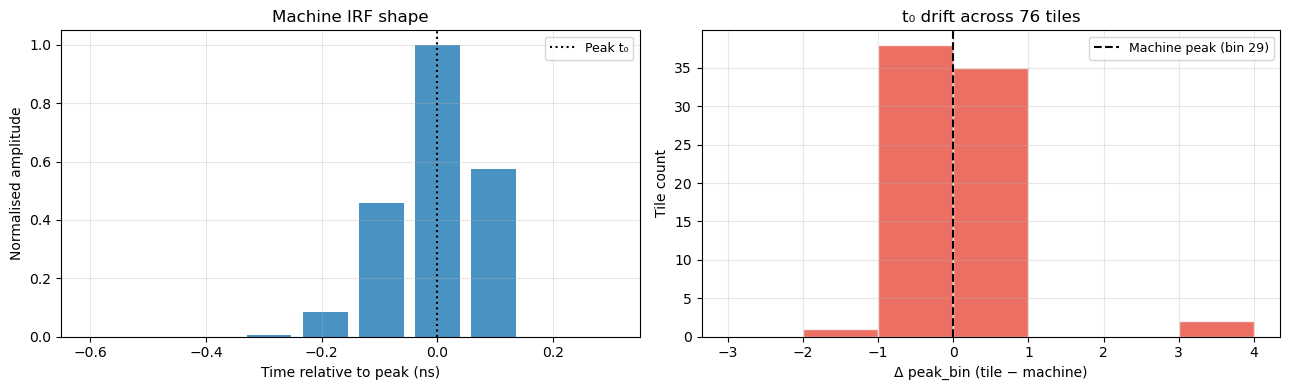

In [10]:
# ── QC: machine IRF shape + per-tile t₀ drift ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
t_rel = (np.arange(N_MACHINE) - PI_MACHINE) * BW_NS
nz = machine_irf > 0
ax.bar(t_rel[nz], machine_irf[nz]/machine_irf.max(),
       width=BW_NS*0.8, color='#2980b9', alpha=0.85)
ax.axvline(0, color='k', ls=':', lw=1.5, label='Peak t₀')
ax.set_xlabel('Time relative to peak (ns)')
ax.set_ylabel('Normalised amplitude')
ax.set_title('Machine IRF shape')
ax.set_xlim(-0.65, 0.35); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax2 = axes[1]
if 'tile_results' in dir() and tile_results:
    deltas = [tr['peak_bin'] - PI_MACHINE for tr in tile_results]
    ax2.hist(deltas, bins=range(min(deltas)-1, max(deltas)+2),
             color='#e74c3c', alpha=0.8, edgecolor='white')
    ax2.axvline(0, color='k', ls='--', lw=1.5, label=f'Machine peak (bin {PI_MACHINE})')
    ax2.set_xlabel('Δ peak_bin (tile − machine)')
    ax2.set_ylabel('Tile count')
    ax2.set_title(f't₀ drift across {len(tile_results)} tiles')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
    
    # Also report chi2_r distribution
    # chi2rs = [tr['chi2r_tail'] for tr in tile_results]
    # print(f"χ²_r tail across tiles:  "
    #       f"median={np.median(chi2rs):.3f}  "
    #       f"min={np.min(chi2rs):.3f}  max={np.max(chi2rs):.3f}")
    # n_bad = sum(c > 2 for c in chi2rs)
    # if n_bad:
    #     print(f"  ⚠  {n_bad} tiles with χ²_r > 2 — check IRF or fitting range")
else:
    ax2.text(0.5, 0.5, 'Run tiled loop\nto populate',
             ha='center', va='center', transform=ax2.transAxes, fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'irf_qc.png', dpi=150, bbox_inches='tight')
plt.show()


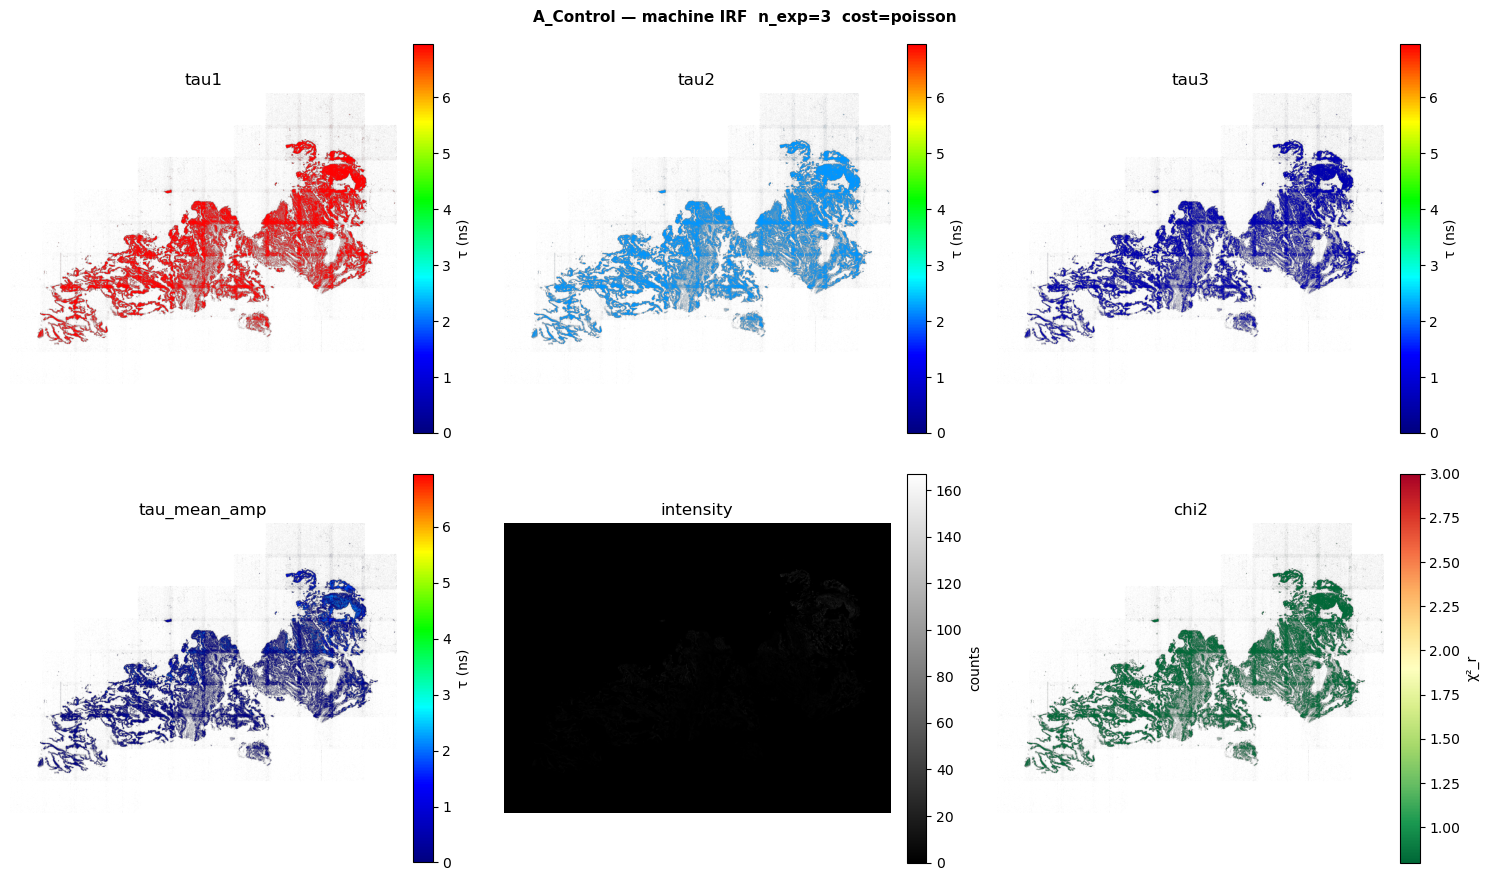

Saved → output/lifetime_maps.png


In [11]:
# ── Lifetime map visualisation ────────────────────────────────────────────────
if 'canvas' not in dir():
    print("No canvas — run assemble step first")
else:
    keys = ([f'tau{k}' for k in range(1, N_EXP+1)]
            + ['tau_mean_amp', 'intensity', 'chi2'])
    keys = [k for k in keys if k in canvas]

    ncols = min(3, len(keys))
    nrows = (len(keys) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows), squeeze=False)
    axes = axes.flatten()

    tau_data = np.concatenate([canvas[k].ravel() for k in keys
                                if 'tau' in k and np.any(np.isfinite(canvas[k]))])
    vmin_t, vmax_t = np.nanpercentile(tau_data, [2, 98])

    for ax, key in zip(axes, keys):
        arr = canvas[key]
        if 'tau' in key:
            im = ax.imshow(arr, cmap=FLIM_CMAP, vmin=vmin_t, vmax=vmax_t)
            plt.colorbar(im, ax=ax, label='τ (ns)', fraction=0.046, pad=0.04)
        elif key == 'chi2':
            im = ax.imshow(arr, cmap='RdYlGn_r', vmin=0.8, vmax=3.0)
            plt.colorbar(im, ax=ax, label='χ²_r', fraction=0.046, pad=0.04)
        else:
            im = ax.imshow(arr, cmap='gray')
            plt.colorbar(im, ax=ax, label='counts', fraction=0.046, pad=0.04)
        ax.set_title(key); ax.axis('off')
    for ax in axes[len(keys):]:
        ax.axis('off')

    plt.suptitle(f'{PTU_BASENAME} — machine IRF  n_exp={N_EXP}  cost={COST_FN}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'lifetime_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {OUTPUT_DIR / 'lifetime_maps.png'}")


In [12]:
# ── Intensity-weighted lifetime image ─────────────────────────────────────────
# Delegates entirely to make_lifetime_image() in flimkit/utils/lifetime_image.py.
# Edit TAU_MIN/MAX and GAMMA here; everything else is handled in that function.
#
# Output files:
#   <roi>_tau_intensity_weighted.tif      — uint16, 0=tau_min, 65535=tau_max
#   <roi>_tau_intensity_weighted.png      — pure RGB image, no axes
#   <roi>_tau_intensity_weighted_preview.png — annotated with colourbar

from flimkit.utils.lifetime_image import make_lifetime_image

if 'canvas' not in dir():
    print("No canvas — run assembly step first")
else:
    TAU_MIN_DISPLAY = 0.0   # ns — lower bound of colour scale
    TAU_MAX_DISPLAY = 5.0   # ns — upper bound of colour scale
    SMOOTH_SIGMA_PX = 2.0   # Gaussian σ for seam removal (pixels)
    GAMMA           = 0.4   # intensity gamma: <1 boosts dim pixels

    make_lifetime_image(
        canvas          = canvas,
        output_dir      = OUTPUT_DIR,
        roi_name        = PTU_BASENAME.replace(' ', '_'),
        tau_min_ns      = TAU_MIN_DISPLAY,
        tau_max_ns      = TAU_MAX_DISPLAY,
        smooth_sigma_px = SMOOTH_SIGMA_PX,
        gamma           = GAMMA,
        verbose         = True,
    )


  ✓ τ TIFF → output/A_Control_tau_intensity_weighted.tif  (uint16, 0.0–5.0 ns → 0–65535)
  intensity  lo=0  hi=19.0  median=2.0  gamma=0.4
  ✓ lifetime PNG → output/A_Control_tau_intensity_weighted.png
  ✓ preview PNG → output/A_Control_tau_intensity_weighted_preview.png
  τ_amp  median=0.000  mean=0.149  p5=0.000  p95=1.281 ns  n=3,405,842


In [13]:
# ── Per-component amplitude RGB TIFF ──────────────────────────────────────────
# R = amplitude fraction of τ₁ (long)
# G = amplitude fraction of τ₂ (mid)       [2-exp and 3-exp only]
# B = amplitude fraction of τ₃ (short)     [3-exp only]
#
# Each channel is independently scaled to uint16 so spatial variation in
# composition is visible regardless of absolute intensity.
# Open in Fiji: Image > Color > Channels Tool to inspect individually.

from flimkit.utils.lifetime_image import make_component_rgb_tiff

if 'canvas' not in dir():
    print("No canvas — run assembly step first")
else:
    make_component_rgb_tiff(
        canvas     = canvas,
        output_dir = OUTPUT_DIR,
        roi_name   = PTU_BASENAME.replace(' ', '_'),
        n_exp      = N_EXP,
        verbose    = True,
    )


  ✓ component RGB TIFF → output/A_Control_component_rgb.tif
    R=τ₁  G=τ₂  B=τ₃  (amplitude fraction, uint16)


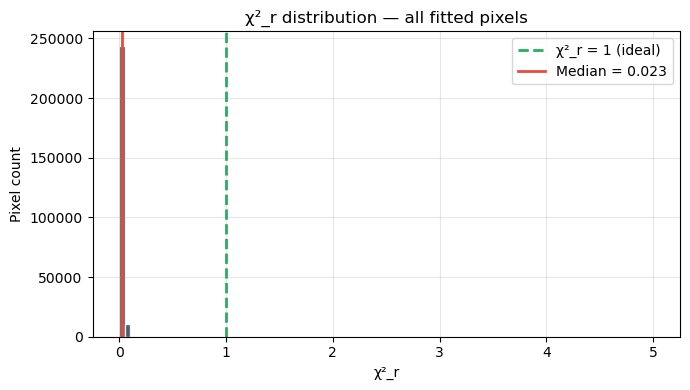

  Median χ²_r : 0.0228
  χ²_r < 2    : 100.0%
  χ²_r > 3    : 0.0%


In [14]:
# ── χ²_r pixel distribution ───────────────────────────────────────────────────
if 'canvas' not in dir():
    print("No canvas — run assemble step first")
else:
    chi2 = canvas['chi2'].ravel()
    chi2 = chi2[np.isfinite(chi2) & (chi2 > 0)]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(chi2, bins=100, range=(0, 5), color='#2c3e50', edgecolor='white', alpha=0.85)
    ax.axvline(1.0, color='#27ae60', ls='--', lw=2, label='χ²_r = 1 (ideal)')
    ax.axvline(np.median(chi2), color='#e74c3c', ls='-', lw=2,
               label=f'Median = {np.median(chi2):.3f}')
    ax.set_xlabel('χ²_r'); ax.set_ylabel('Pixel count')
    ax.set_title('χ²_r distribution — all fitted pixels')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'chi2_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Median χ²_r : {np.median(chi2):.4f}")
    print(f"  χ²_r < 2    : {(chi2 < 2).mean()*100:.1f}%")
    print(f"  χ²_r > 3    : {(chi2 > 3).mean()*100:.1f}%")
